In [1]:
!pip -q install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Number of words kept in the vocabulary
VOCAB_SIZE = 10000

# Maximum review length
MAX_LENGTH = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First review length:", len(X_train[0]))
print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review length: 218
First label: 1


In [3]:
# Make all reviews the same length
X_train_pad = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [4]:
print("Unique labels:", np.unique(y_train))
print("Positive reviews:", np.sum(y_train == 1))
print("Negative reviews:", np.sum(y_train == 0))

Unique labels: [0 1]
Positive reviews: 12500
Negative reviews: 12500


2. Build the RNN/LSTM model

In [5]:
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

3. Train the model

In [6]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.5110 - loss: 0.6925 - val_accuracy: 0.5720 - val_loss: 0.6760
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 402ms/step - accuracy: 0.6863 - loss: 0.5930 - val_accuracy: 0.7980 - val_loss: 0.4981
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 430ms/step - accuracy: 0.7307 - loss: 0.5611 - val_accuracy: 0.5744 - val_loss: 0.6679
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 389ms/step - accuracy: 0.6090 - loss: 0.6741 - val_accuracy: 0.5346 - val_loss: 0.6898


4. Evaluate


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

5. Plot training performance

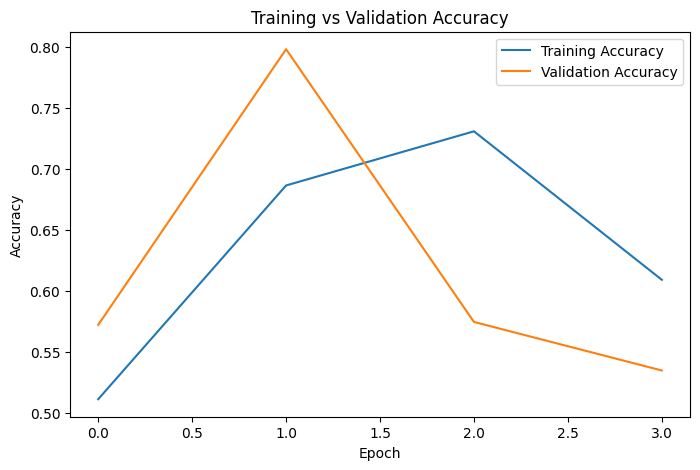

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

6. Create prediction function

In [8]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()

    encoded = []

    for word in words:
        index = word_index.get(word, 2)

        # Keep only words within vocabulary
        if index < VOCAB_SIZE:
            encoded.append(index)

    return pad_sequences(
        [encoded],
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )


def predict_sentiment(review):

    encoded_review = encode_review(review)

    probability = model.predict(
        encoded_review,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Confidence:", round(float(probability), 4))

    return sentiment

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


7. Test your model

In [9]:
predict_sentiment(
    "This movie was amazing and I really enjoyed it"
)

Review: This movie was amazing and I really enjoyed it
Prediction: Positive
Confidence: 0.6589


'Positive'

In [10]:
predict_sentiment(
    "This movie was boring and extremely disappointing"
)

Review: This movie was boring and extremely disappointing
Prediction: Positive
Confidence: 0.6589


'Positive'

8. Save the trained model

In [11]:
model.save("sentiment_lstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


9. Create a simple AI interface

In [12]:
def sentiment_analyzer():

    review = input("Enter a movie review: ")

    prediction = predict_sentiment(review)

    return prediction

In [13]:
sentiment_analyzer()

Enter a movie review: This movie was amazing and I really enjoyed it
Review: This movie was amazing and I really enjoyed it
Prediction: Positive
Confidence: 0.6589


'Positive'

10. GitHub README

# AI Sentiment Analysis using RNN and LSTM

An end-to-end Natural Language Processing project that classifies movie reviews as positive or negative using a Recurrent Neural Network based on LSTM.

## Features

- Text data preprocessing
- Tokenization and sequence encoding
- Sequence padding
- Word embeddings
- LSTM-based deep learning model
- Dropout regularization
- Early stopping
- Model evaluation
- Real-time sentiment prediction
- Trained model serialization

## Tech Stack

- Python
- NumPy
- Pandas
- TensorFlow
- Keras
- Matplotlib

## Workflow

```text
Movie Reviews
      ↓
Text Preprocessing
      ↓
Tokenization
      ↓
Sequence Encoding
      ↓
Padding
      ↓
Word Embedding
      ↓
LSTM
      ↓
Dropout
      ↓
Dense Layer
      ↓
Sentiment Prediction